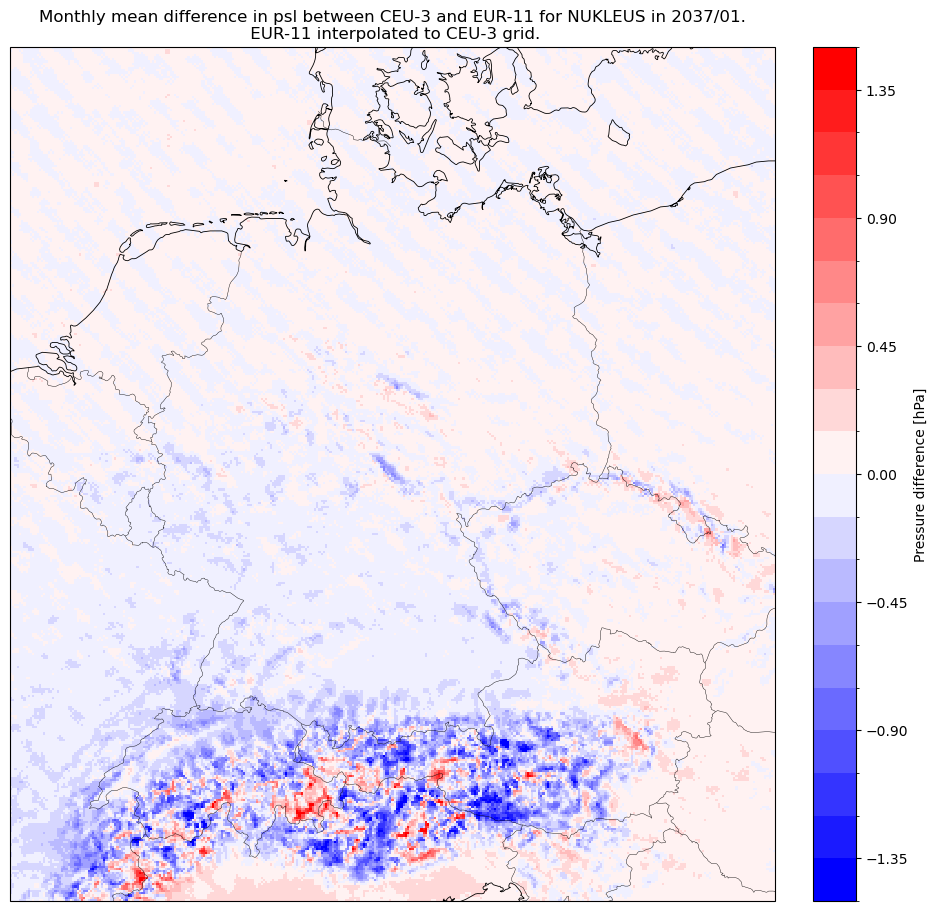

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm

CEU3_file = "/work/bb1203/data_NUKLEUS_CMOR/CEU-3/CLMcom-BTU/MPI-M-MPI-ESM1-2-HR/ssp370-GWL2K/r1i1p1f1/CLMcom-BTU-ICON-2-6-5-rc/nukleus-x2yn2-v1/mon/psl/v20240201/psl_CEU-3_MPI-M-MPI-ESM1-2-HR_ssp370-GWL2K_r1i1p1f1_CLMcom-BTU-ICON-2-6-5-rc_nukleus-x2yn2-v1_mon_203701-204012.nc"
EUR11_file = "/work/bb1203/data_NUKLEUS_CMOR/EUR-11/CLMcom-BTU/MPI-M-MPI-ESM1-2-HR/ssp370/r1i1p1f1/CLMcom-BTU-ICON-2-6-5-rc/v1/mon/psl/v20240201/psl_EUR-11_MPI-M-MPI-ESM1-2-HR_ssp370_r1i1p1f1_CLMcom-BTU-ICON-2-6-5-rc_v1_mon_203101-204012.nc"
rotated_pole = ccrs.RotatedPole(pole_longitude=198.0, pole_latitude=39.25)

# Create figure for all turbines: 2 rows × 3 cols
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(14, 9),
    subplot_kw=dict(projection=rotated_pole),
    layout="compressed",
)

levels = np.arange(-1.5, 1.5 + 0.15, 0.15)
norm = BoundaryNorm(levels, ncolors=plt.get_cmap("bwr").N, clip=True)

with xr.open_dataset(CEU3_file) as df, xr.open_dataset(EUR11_file) as dx:
    psl_3 = df["psl"].sel(time="2037-01-16")
    psl_11 = dx["psl"].sel(time="2037-01-16")

    lon = df["lon"].values
    lat = df["lat"].values

    # Interpolate EUR-11 onto CEU-3 grid
    psl_11_on_ceu3 = psl_11.interp(rlon=df["rlon"], rlat=df["rlat"], method="linear")

    diff = psl_3 - psl_11_on_ceu3
    diff = np.squeeze(diff.values / 100)

    pm = ax.pcolormesh(
        lon,
        lat,
        diff,
        shading="auto",
        norm=norm,
        transform=ccrs.PlateCarree(),
        rasterized=True,
        cmap="bwr",
    )
    ax.set_title(
        "Monthly mean difference in psl between CEU-3 and EUR-11 for NUKLEUS in 2037/01.\n EUR-11 interpolated to CEU-3 grid."
    )
    plt.colorbar(pm, label="Pressure difference [hPa]")
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    plt.show()